# 04 - Sequence Autoencoder

Sequence-aware autoencoder using short telemetry windows instead of single timestamps.

This version improves detection by reconstructing local temporal context over a rolling window, which is a better match for episodic satellite anomalies than a pointwise autoencoder.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from src.utils.preprocessing import (
    generate_synthetic_dataset, preprocess_pipeline, FEATURE_COLUMNS,
    build_feature_weights,
)
from src.models.autoencoder import SatelliteAutoencoder


def make_windows(frame, cols, window_size=12, center_label=True):
    values = frame[cols].values
    labels = frame['label'].values if 'label' in frame.columns else None
    windows, y = [], []
    half = window_size // 2
    for end in range(window_size, len(frame) + 1):
        start = end - window_size
        windows.append(values[start:end].reshape(-1))
        if labels is not None:
            if center_label:
                y.append(labels[start + half])
            else:
                y.append(labels[start:end].max())
    windows = np.asarray(windows, dtype=np.float32)
    y = None if labels is None else np.asarray(y, dtype=int)
    return windows, y


df = generate_synthetic_dataset(n_samples=120_000, seed=42)
feature_cols = [c for c in FEATURE_COLUMNS if c in df.columns]
train, val, test, scaler, all_feature_cols = preprocess_pipeline(df, feature_cols)

# Curated features: base sensors + z-scores + physics + orbital
# (skip rolling mean/std — they add dimensionality without discrimination)
seq_cols = [c for c in all_feature_cols if c in train.columns
            and '_roll_mean' not in c and '_roll_std' not in c]

train_normal = train.loc[train['label'] == 0]
val_normal = val.loc[val['label'] == 0]
window_size = 12

X_train, _ = make_windows(train_normal, seq_cols, window_size=window_size)
X_val, _ = make_windows(val_normal, seq_cols, window_size=window_size)
X_val_full, y_val = make_windows(val, seq_cols, window_size=window_size)
X_test, y_test = make_windows(test, seq_cols, window_size=window_size)

# Domain feature weights (tiled across window inside the model)
feature_weights = build_feature_weights(seq_cols)

print(f'Window size: {window_size} steps')
print(f'Features per step: {len(seq_cols)}  |  Flattened input dim: {X_train.shape[1]}')
print(f'Train windows: {len(X_train)}  |  Val windows: {len(X_val)}  |  Test windows: {len(X_test)}')
print(f'Anomaly rate (test): {y_test.mean():.4f}')

Window size: 12 steps
Features per step: 50  |  Flattened input dim: 600
Train windows: 80575  |  Val windows: 17457  |  Test windows: 17989
Anomaly rate (test): 0.0341


In [2]:
model = SatelliteAutoencoder(
    input_dim=X_train.shape[1],
    hidden_dims=(384, 192, 96),
    latent_dim=48,
    epochs=120,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    threshold_percentile=97,
    feature_weights=feature_weights,
)
model.fit(X_train, X_val)

# Tune the threshold on validation windows to improve the operating point.
val_scores = model.anomaly_scores(X_val_full)
threshold_grid = np.quantile(val_scores, np.linspace(0.80, 0.995, 40))
best_threshold = model.threshold_
best_f1 = -1.0
for threshold in threshold_grid:
    y_val_pred = (val_scores > threshold).astype(int)
    tp = ((y_val_pred == 1) & (y_val == 1)).sum()
    precision = tp / max((y_val_pred == 1).sum(), 1)
    recall = tp / max((y_val == 1).sum(), 1)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = float(threshold)

model.threshold_ = best_threshold
scores = model.anomaly_scores(X_test)
metrics = model.evaluate(X_test, y_test)
print(f'Tuned threshold: {model.threshold_:.4f}')
for k, v in metrics.items(): print(f'  {k}: {v:.4f}')

Tuned threshold: 0.0009
  precision: 0.5342
  recall: 0.4446
  f1: 0.4853
  roc_auc: 0.8207


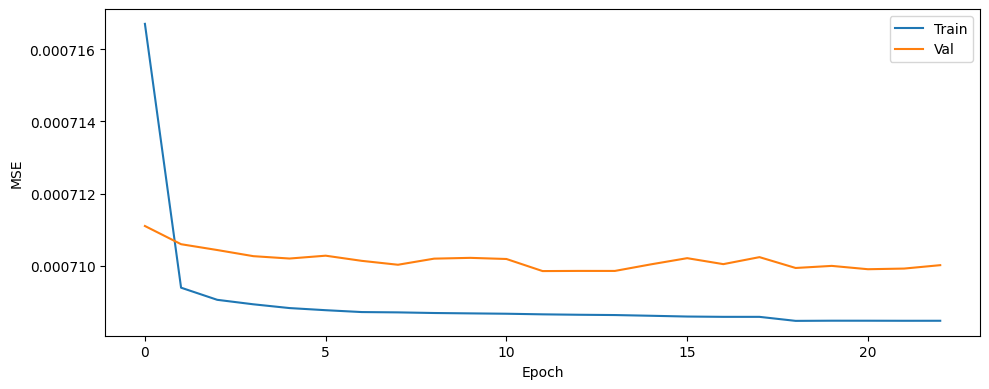

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(model.train_losses_, label='Train')
if model.val_losses_: ax.plot(model.val_losses_, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.savefig('../results/ae_training_curve.png', dpi=100); plt.show()

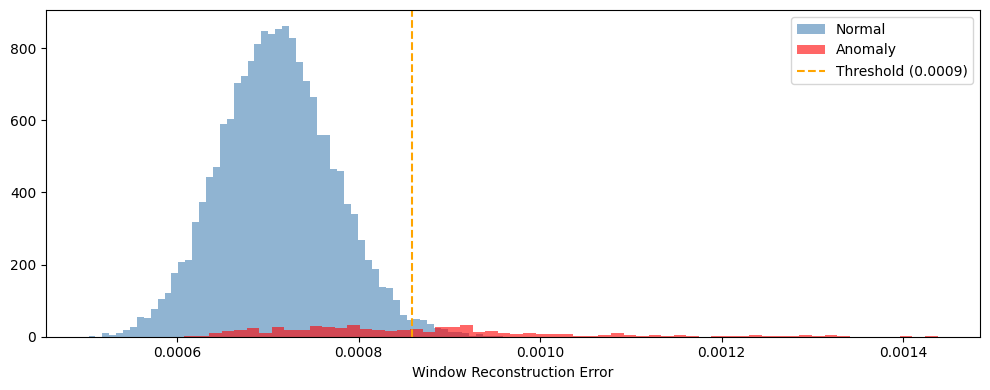

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[y_test==0], bins=60, alpha=0.6, label='Normal', color='steelblue')
ax.hist(scores[y_test==1], bins=60, alpha=0.6, label='Anomaly', color='red')
ax.axvline(model.threshold_, color='orange', linestyle='--', label=f'Threshold ({model.threshold_:.4f})')
ax.set_xlabel('Window Reconstruction Error'); ax.legend()
plt.tight_layout(); plt.savefig('../results/reconstruction_error_hist.png', dpi=100); plt.show()

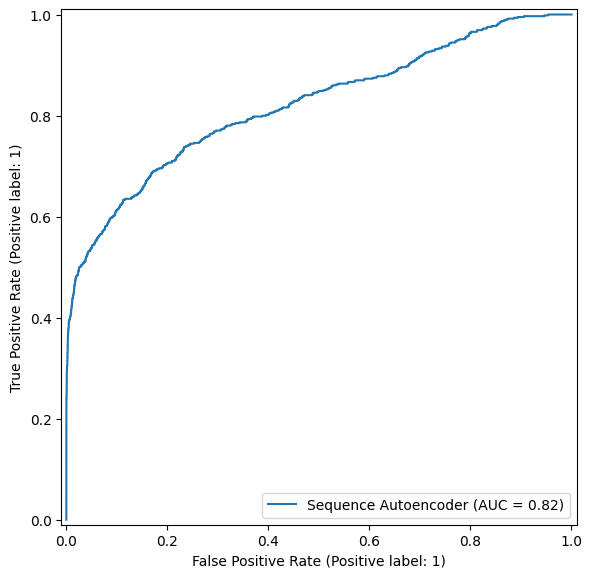

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, scores, ax=ax, name='Sequence Autoencoder')
plt.tight_layout(); plt.savefig('../results/roc_curve.png', dpi=100); plt.show()